# COMP6001 Assignment 1
## Image Restoration and Object Detection
Name: Xiang Lu
Date: 2026-03-25

## 1. Environment Setup

In [74]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
from collections import Counter
from ultralytics import YOLO
from skimage.restoration import wiener
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Blur and Sharp Images

In [75]:
blur_dir = "data/blur"
sharp_dir = "data/sharp"

blur_files = os.listdir(blur_dir) if os.path.exists(blur_dir) else []
sharp_files = os.listdir(sharp_dir) if os.path.exists(sharp_dir) else []

print("Blur images:", len(blur_files))
print("Sharp images:", len(sharp_files))
print("First few blur files:", blur_files[:5])
print("First few sharp files:", sharp_files[:5])

Blur images: 200
Sharp images: 200
First few blur files: ['000001.png', '000002.png', '000003.png', '000004.png', '000005.png']
First few sharp files: ['000001.png', '000002.png', '000003.png', '000004.png', '000005.png']


## 3. Check Image Pair Consistency

In [76]:
blur_files = sorted(blur_files)
sharp_files = sorted(sharp_files)

print("Number of blur images:", len(blur_files))
print("Number of sharp images:", len(sharp_files))

if len(blur_files) != len(sharp_files):
    print("Warning: The number of blur and sharp images does not match.")
else:
    print("The number of blur and sharp images matches.")

matched = True
for b, s in zip(blur_files, sharp_files):
    if b != s:
        matched = False
        print("Mismatch found:", b, s)

if matched:
    print("All blur and sharp filenames are correctly matched.")

Number of blur images: 200
Number of sharp images: 200
The number of blur and sharp images matches.
All blur and sharp filenames are correctly matched.


## 4. Preview a Blur-Sharp Image Pair

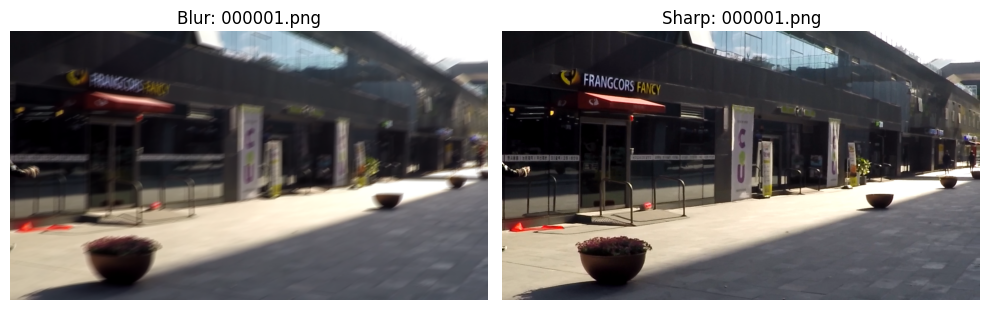

In [77]:
sample_index = 0

blur_path = os.path.join(blur_dir, blur_files[sample_index])
sharp_path = os.path.join(sharp_dir, sharp_files[sample_index])

blur_img = cv2.imread(blur_path)
sharp_img = cv2.imread(sharp_path)

blur_img_rgb = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
sharp_img_rgb = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(blur_img_rgb)
plt.title(f"Blur: {blur_files[sample_index]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharp_img_rgb)
plt.title(f"Sharp: {sharp_files[sample_index]}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Baseline Image Restoration with Unsharp Masking

In [78]:
def unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.5):
    blurred = cv2.GaussianBlur(image, kernel_size, sigma)
    sharpened = cv2.addWeighted(image, 1 + amount, blurred, -amount, 0)
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    return sharpened

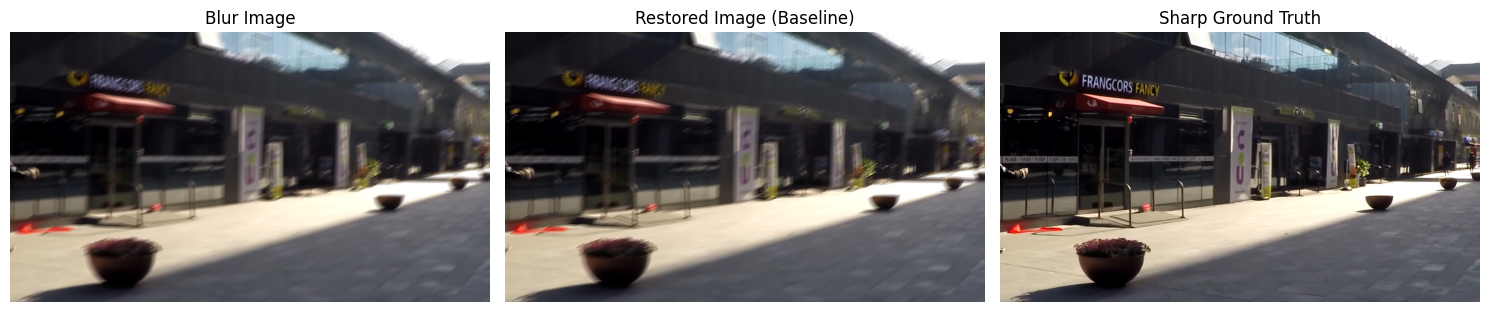

In [79]:
sample_index = 0

blur_path = os.path.join(blur_dir, blur_files[sample_index])
sharp_path = os.path.join(sharp_dir, sharp_files[sample_index])

blur_img = cv2.imread(blur_path)
sharp_img = cv2.imread(sharp_path)

restored_img = unsharp_mask(blur_img, kernel_size=(5, 5), sigma=1.0, amount=1.5)

blur_img_rgb = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
restored_img_rgb = cv2.cvtColor(restored_img, cv2.COLOR_BGR2RGB)
sharp_img_rgb = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blur_img_rgb)
plt.title("Blur Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(restored_img_rgb)
plt.title("Restored Image (Baseline)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_img_rgb)
plt.title("Sharp Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

A simple sharpening-based baseline provides only limited visual improvement and cannot effectively recover details lost under motion blur.    

## 6. Quantitative Evaluation

In [80]:
# Convert images to RGB for evaluation
blur_eval = blur_img_rgb
restored_eval = restored_img_rgb
sharp_eval = sharp_img_rgb

# MSE
mse_blur = mean_squared_error(sharp_eval, blur_eval)
mse_restored = mean_squared_error(sharp_eval, restored_eval)

# PSNR
psnr_blur = peak_signal_noise_ratio(sharp_eval, blur_eval, data_range=255)
psnr_restored = peak_signal_noise_ratio(sharp_eval, restored_eval, data_range=255)

# SSIM
ssim_blur = structural_similarity(sharp_eval, blur_eval, channel_axis=2, data_range=255)
ssim_restored = structural_similarity(sharp_eval, restored_eval, channel_axis=2, data_range=255)

print("Blur vs Sharp")
print("MSE :", mse_blur)
print("PSNR:", psnr_blur)
print("SSIM:", ssim_blur)

print("\nRestored vs Sharp")
print("MSE :", mse_restored)
print("PSNR:", psnr_restored)
print("SSIM:", ssim_restored)

Blur vs Sharp
MSE : 233.85400209780093
PSNR: 24.441355541918355
SSIM: 0.8031461222795954

Restored vs Sharp
MSE : 240.99582212094907
PSNR: 24.310708471127317
SSIM: 0.7922079042536172


The unsharp masking baseline did not improve image quality for this motion-blurred sample. Instead, it slightly worsened MSE, PSNR, and SSIM compared with the original blurred image. This suggests that simple sharpening is not suitable for recovering details lost under motion blur.

## 7. Batch Evaluation of Unsharp Masking Baseline

In [81]:
def evaluate_pair_metrics(reference_rgb, test_rgb):
    mse_value = mean_squared_error(reference_rgb, test_rgb)
    psnr_value = peak_signal_noise_ratio(reference_rgb, test_rgb, data_range=255)
    ssim_value = structural_similarity(reference_rgb, test_rgb, channel_axis=2, data_range=255)
    return mse_value, psnr_value, ssim_value

In [82]:
unsharp_results = []

for file_name in blur_files:
    blur_path = os.path.join(blur_dir, file_name)
    sharp_path = os.path.join(sharp_dir, file_name)

    blur_img = cv2.imread(blur_path)
    sharp_img = cv2.imread(sharp_path)

    if blur_img is None or sharp_img is None:
        print(f"Skipping {file_name} because an image could not be loaded.")
        continue

    restored_img = unsharp_mask(blur_img, kernel_size=(5, 5), sigma=1.0, amount=1.5)

    blur_rgb = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
    sharp_rgb = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)
    restored_rgb = cv2.cvtColor(restored_img, cv2.COLOR_BGR2RGB)

    mse_blur, psnr_blur, ssim_blur = evaluate_pair_metrics(sharp_rgb, blur_rgb)
    mse_restored, psnr_restored, ssim_restored = evaluate_pair_metrics(sharp_rgb, restored_rgb)

    unsharp_results.append({
        "file_name": file_name,
        "mse_blur": mse_blur,
        "psnr_blur": psnr_blur,
        "ssim_blur": ssim_blur,
        "mse_unsharp": mse_restored,
        "psnr_unsharp": psnr_restored,
        "ssim_unsharp": ssim_restored
    })

unsharp_df = pd.DataFrame(unsharp_results)
unsharp_df

,file_name,mse_blur,psnr_blur,ssim_blur,mse_unsharp,psnr_unsharp,ssim_unsharp
0,000001.png,233.854002,24.441356,0.803146,240.995822,24.310708,0.792208
1,000002.png,54.250642,30.786755,0.946296,49.657282,31.170974,0.944916
2,000003.png,112.976025,27.600941,0.893630,116.042101,27.484648,0.886667
3,000004.png,80.061535,29.096564,0.919517,77.870896,29.217052,0.916304
4,000005.png,117.315253,27.437259,0.888787,116.628421,27.462760,0.884089
...,...,...,...,...,...,...,...
195,000196.png,435.980111,21.736137,0.622847,448.050962,21.617529,0.623934
196,000197.png,438.878526,21.707360,0.624407,446.900519,21.628695,0.625720
197,000198.png,614.316931,20.246879,0.503384,628.352067,20.148773,0.500016
198,000199.png,440.247102,21.693839,0.591252,448.611312,21.612101,0.589342


In [83]:
unsharp_summary = pd.DataFrame([{
    "avg_mse_blur": unsharp_df["mse_blur"].mean(),
    "avg_psnr_blur": unsharp_df["psnr_blur"].mean(),
    "avg_ssim_blur": unsharp_df["ssim_blur"].mean(),
    "avg_mse_unsharp": unsharp_df["mse_unsharp"].mean(),
    "avg_psnr_unsharp": unsharp_df["psnr_unsharp"].mean(),
    "avg_ssim_unsharp": unsharp_df["ssim_unsharp"].mean()
}])

unsharp_summary

,avg_mse_blur,avg_psnr_blur,avg_ssim_blur,avg_mse_unsharp,avg_psnr_unsharp,avg_ssim_unsharp
0,196.871627,26.700021,0.837751,200.503163,26.538248,0.830612


### Observation
This table compares the average metrics of the original blurred images and the restored images produced by unsharp masking. The results can be used to determine whether simple sharpening improves restoration quality across the small test set.

## 8. Wiener Filter Baseline

In [84]:
def motion_blur_kernel(length=15, angle=0):
    kernel = np.zeros((length, length), dtype=np.float32)
    kernel[length // 2, :] = np.ones(length, dtype=np.float32)
    
    center = (length / 2 - 0.5, length / 2 - 0.5)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_kernel = cv2.warpAffine(kernel, rotation_matrix, (length, length))
    
    kernel_sum = rotated_kernel.sum()
    if kernel_sum != 0:
        rotated_kernel /= kernel_sum
    
    return rotated_kernel

In [85]:
def apply_wiener_deblur(image_bgr, psf, balance=0.05):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_float = image_rgb.astype(np.float32) / 255.0

    restored_channels = []
    for c in range(3):
        restored_channel = wiener(image_float[:, :, c], psf, balance=balance)
        restored_channel = np.clip(restored_channel, 0, 1)
        restored_channels.append(restored_channel)

    restored_rgb = np.stack(restored_channels, axis=2)
    restored_rgb_uint8 = (restored_rgb * 255).astype(np.uint8)
    restored_bgr_uint8 = cv2.cvtColor(restored_rgb_uint8, cv2.COLOR_RGB2BGR)
    return restored_bgr_uint8

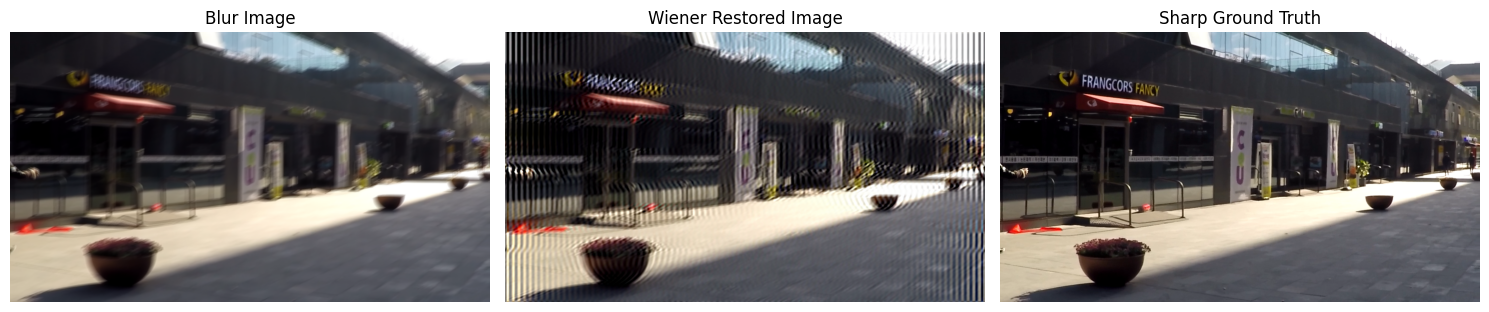

In [86]:
psf = motion_blur_kernel(length=15, angle=0)

sample_index = 0
blur_path = os.path.join(blur_dir, blur_files[sample_index])
sharp_path = os.path.join(sharp_dir, sharp_files[sample_index])

blur_img = cv2.imread(blur_path)
sharp_img = cv2.imread(sharp_path)

wiener_img = apply_wiener_deblur(blur_img, psf, balance=0.05)

blur_rgb = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
wiener_rgb = cv2.cvtColor(wiener_img, cv2.COLOR_BGR2RGB)
sharp_rgb = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blur_rgb)
plt.title("Blur Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(wiener_rgb)
plt.title("Wiener Restored Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_rgb)
plt.title("Sharp Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Batch Evaluation of Wiener Filter

In [87]:
wiener_results = []

psf = motion_blur_kernel(length=15, angle=0)

for file_name in blur_files:
    blur_path = os.path.join(blur_dir, file_name)
    sharp_path = os.path.join(sharp_dir, file_name)

    blur_img = cv2.imread(blur_path)
    sharp_img = cv2.imread(sharp_path)

    if blur_img is None or sharp_img is None:
        print(f"Skipping {file_name} because an image could not be loaded.")
        continue

    wiener_img = apply_wiener_deblur(blur_img, psf, balance=0.05)

    blur_rgb = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
    sharp_rgb = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)
    wiener_rgb = cv2.cvtColor(wiener_img, cv2.COLOR_BGR2RGB)

    mse_blur, psnr_blur, ssim_blur = evaluate_pair_metrics(sharp_rgb, blur_rgb)
    mse_wiener, psnr_wiener, ssim_wiener = evaluate_pair_metrics(sharp_rgb, wiener_rgb)

    wiener_results.append({
        "file_name": file_name,
        "mse_blur": mse_blur,
        "psnr_blur": psnr_blur,
        "ssim_blur": ssim_blur,
        "mse_wiener": mse_wiener,
        "psnr_wiener": psnr_wiener,
        "ssim_wiener": ssim_wiener
    })

wiener_df = pd.DataFrame(wiener_results)
wiener_df

,file_name,mse_blur,psnr_blur,ssim_blur,mse_wiener,psnr_wiener,ssim_wiener
0,000001.png,233.854002,24.441356,0.803146,487.907224,21.247431,0.600499
1,000002.png,54.250642,30.786755,0.946296,1263.068371,17.116535,0.462836
2,000003.png,112.976025,27.600941,0.893630,519.908954,20.971531,0.614210
3,000004.png,80.061535,29.096564,0.919517,1655.293288,15.942054,0.412584
4,000005.png,117.315253,27.437259,0.888787,1463.150385,16.477914,0.430101
...,...,...,...,...,...,...,...
195,000196.png,435.980111,21.736137,0.622847,823.934747,18.971875,0.527529
196,000197.png,438.878526,21.707360,0.624407,793.401147,19.135875,0.514129
197,000198.png,614.316931,20.246879,0.503384,1063.120883,17.864977,0.363659
198,000199.png,440.247102,21.693839,0.591252,1080.975183,17.792646,0.375433


In [88]:
wiener_summary = pd.DataFrame([{
    "avg_mse_blur": wiener_df["mse_blur"].mean(),
    "avg_psnr_blur": wiener_df["psnr_blur"].mean(),
    "avg_ssim_blur": wiener_df["ssim_blur"].mean(),
    "avg_mse_wiener": wiener_df["mse_wiener"].mean(),
    "avg_psnr_wiener": wiener_df["psnr_wiener"].mean(),
    "avg_ssim_wiener": wiener_df["ssim_wiener"].mean()
}])

wiener_summary

,avg_mse_blur,avg_psnr_blur,avg_ssim_blur,avg_mse_wiener,avg_psnr_wiener,avg_ssim_wiener
0,196.871627,26.700021,0.837751,1246.612372,17.705634,0.426792


## 10. Baseline Comparison Summary

In [89]:
comparison_df = pd.DataFrame([
    {
        "method": "Blur",
        "avg_mse": unsharp_df["mse_blur"].mean(),
        "avg_psnr": unsharp_df["psnr_blur"].mean(),
        "avg_ssim": unsharp_df["ssim_blur"].mean()
    },
    {
        "method": "Unsharp Masking",
        "avg_mse": unsharp_df["mse_unsharp"].mean(),
        "avg_psnr": unsharp_df["psnr_unsharp"].mean(),
        "avg_ssim": unsharp_df["ssim_unsharp"].mean()
    },
    {
        "method": "Wiener Filter",
        "avg_mse": wiener_df["mse_wiener"].mean(),
        "avg_psnr": wiener_df["psnr_wiener"].mean(),
        "avg_ssim": wiener_df["ssim_wiener"].mean()
    }
])

comparison_df

,method,avg_mse,avg_psnr,avg_ssim
0,Blur,196.871627,26.700021,0.837751
1,Unsharp Masking,200.503163,26.538248,0.830612
2,Wiener Filter,1246.612372,17.705634,0.426792


In [90]:
best_psnr_method = comparison_df.loc[comparison_df["avg_psnr"].idxmax(), "method"]
best_ssim_method = comparison_df.loc[comparison_df["avg_ssim"].idxmax(), "method"]
best_mse_method = comparison_df.loc[comparison_df["avg_mse"].idxmin(), "method"]

print("Best method by PSNR:", best_psnr_method)
print("Best method by SSIM:", best_ssim_method)
print("Best method by MSE :", best_mse_method)

Best method by PSNR: Blur
Best method by SSIM: Blur
Best method by MSE : Blur


## 11. Object Detection and Analysis

In [91]:
def run_detection_on_bgr(image_bgr, model, conf=0.25):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    results = model.predict(image_rgb, conf=conf, verbose=False)
    return results[0]

def extract_detection_summary(result):
    if result.boxes is None or len(result.boxes) == 0:
        return {
            "num_detections": 0,
            "mean_confidence": 0.0,
            "classes": [],
            "class_counts": {}
        }

    class_ids = result.boxes.cls.cpu().numpy().astype(int).tolist()
    confidences = result.boxes.conf.cpu().numpy().tolist()
    class_names = [result.names[c] for c in class_ids]
    class_counts = dict(Counter(class_names))

    return {
        "num_detections": len(class_ids),
        "mean_confidence": float(np.mean(confidences)),
        "classes": class_names,
        "class_counts": class_counts
    }

def show_detection_result(image_bgr, result, title="Detection Result", figsize=(8, 6)):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image_rgb)
    ax.set_title(title)
    ax.axis("off")

    if result.boxes is not None and len(result.boxes) > 0:
        boxes = result.boxes.xyxy.cpu().numpy()
        scores = result.boxes.conf.cpu().numpy()
        class_ids = result.boxes.cls.cpu().numpy().astype(int)

        for box, score, cls_id in zip(boxes, scores, class_ids):
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1

            rect = patches.Rectangle(
                (x1, y1), width, height,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)

            label = f"{result.names[cls_id]} {score:.2f}"
            ax.text(
                x1, max(y1 - 5, 5), label,
                fontsize=10, color="white",
                bbox=dict(facecolor="red", alpha=0.7)
            )

    plt.show()

In [92]:
detector = YOLO("yolov8n.pt")
print("Pretrained YOLO model loaded.")

Pretrained YOLO model loaded.


Blurred image summary:
{'num_detections': 1, 'mean_confidence': 0.32427340745925903, 'classes': ['car'], 'class_counts': {'car': 1}}

Deblurred image summary:
{'num_detections': 1, 'mean_confidence': 0.3055916130542755, 'classes': ['car'], 'class_counts': {'car': 1}}


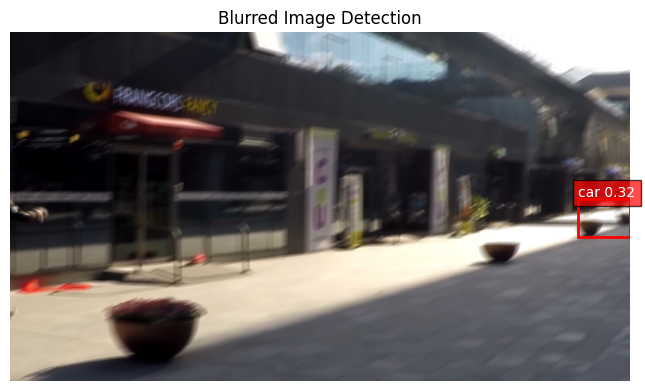

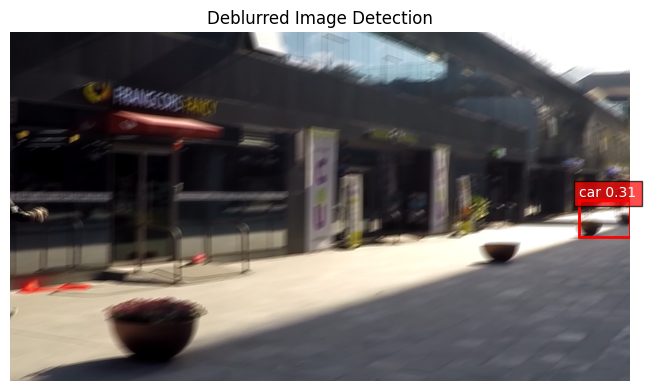

In [93]:
sample_index = 0

blur_path = os.path.join(blur_dir, blur_files[sample_index])
blur_img_bgr = cv2.imread(blur_path)

deblur_img_bgr = unsharp_mask(blur_img_bgr, kernel_size=(5, 5), sigma=1.0, amount=1.5)

blur_result = run_detection_on_bgr(blur_img_bgr, detector, conf=0.25)
deblur_result = run_detection_on_bgr(deblur_img_bgr, detector, conf=0.25)

blur_summary = extract_detection_summary(blur_result)
deblur_summary = extract_detection_summary(deblur_result)

print("Blurred image summary:")
print(blur_summary)

print("\nDeblurred image summary:")
print(deblur_summary)

show_detection_result(blur_img_bgr, blur_result, title="Blurred Image Detection")
show_detection_result(deblur_img_bgr, deblur_result, title="Deblurred Image Detection")

In [94]:
task3_results = []
max_images = min(20, len(blur_files))

for file_name in blur_files[:max_images]:
    blur_path = os.path.join(blur_dir, file_name)
    blur_img_bgr = cv2.imread(blur_path)

    if blur_img_bgr is None:
        continue

    deblur_img_bgr = unsharp_mask(blur_img_bgr, kernel_size=(5, 5), sigma=1.0, amount=1.5)

    blur_result = run_detection_on_bgr(blur_img_bgr, detector, conf=0.25)
    deblur_result = run_detection_on_bgr(deblur_img_bgr, detector, conf=0.25)

    blur_summary = extract_detection_summary(blur_result)
    deblur_summary = extract_detection_summary(deblur_result)

    task3_results.append({
        "file_name": file_name,
        "blur_num_detections": blur_summary["num_detections"],
        "deblur_num_detections": deblur_summary["num_detections"],
        "blur_mean_confidence": blur_summary["mean_confidence"],
        "deblur_mean_confidence": deblur_summary["mean_confidence"],
        "blur_classes": ", ".join(sorted(set(blur_summary["classes"]))),
        "deblur_classes": ", ".join(sorted(set(deblur_summary["classes"])))
    })

task3_df = pd.DataFrame(task3_results)
task3_df.head(10)

,file_name,blur_num_detections,deblur_num_detections,blur_mean_confidence,deblur_mean_confidence,blur_classes,deblur_classes
0,000001.png,1,1,0.324273,0.305592,car,car
1,000002.png,2,3,0.461488,0.392522,bowl,"bowl, potted plant"
2,000003.png,2,2,0.546285,0.522649,bowl,bowl
3,000004.png,4,4,0.363489,0.415234,"bowl, person, potted plant","bowl, person, potted plant"
4,000005.png,0,0,0.000000,0.000000,,
5,000006.png,1,1,0.282505,0.327826,bowl,bowl
6,000007.png,3,2,0.383358,0.406421,"bowl, person",bowl
7,000008.png,0,1,0.000000,0.255802,,bowl
8,000009.png,1,1,0.461795,0.463770,train,train
9,000010.png,2,2,0.402009,0.404432,"bowl, train","bowl, train"


In [95]:
task3_summary = pd.DataFrame([{
    "avg_blur_num_detections": task3_df["blur_num_detections"].mean(),
    "avg_deblur_num_detections": task3_df["deblur_num_detections"].mean(),
    "avg_blur_confidence": task3_df["blur_mean_confidence"].mean(),
    "avg_deblur_confidence": task3_df["deblur_mean_confidence"].mean()
}])

task3_summary

,avg_blur_num_detections,avg_deblur_num_detections,avg_blur_confidence,avg_deblur_confidence
0,1.5,1.7,0.334051,0.354423


In [96]:
task3_df["delta_num_detections"] = task3_df["deblur_num_detections"] - task3_df["blur_num_detections"]
task3_df["delta_confidence"] = task3_df["deblur_mean_confidence"] - task3_df["blur_mean_confidence"]

task3_df[[
    "file_name",
    "blur_num_detections",
    "deblur_num_detections",
    "delta_num_detections",
    "blur_mean_confidence",
    "deblur_mean_confidence",
    "delta_confidence"
]].head(10)

,file_name,blur_num_detections,deblur_num_detections,delta_num_detections,blur_mean_confidence,deblur_mean_confidence,delta_confidence
0,000001.png,1,1,0,0.324273,0.305592,-0.018682
1,000002.png,2,3,1,0.461488,0.392522,-0.068966
2,000003.png,2,2,0,0.546285,0.522649,-0.023636
3,000004.png,4,4,0,0.363489,0.415234,0.051745
4,000005.png,0,0,0,0.000000,0.000000,0.000000
5,000006.png,1,1,0,0.282505,0.327826,0.045321
6,000007.png,3,2,-1,0.383358,0.406421,0.023064
7,000008.png,0,1,1,0.000000,0.255802,0.255802
8,000009.png,1,1,0,0.461795,0.463770,0.001975
9,000010.png,2,2,0,0.402009,0.404432,0.002423


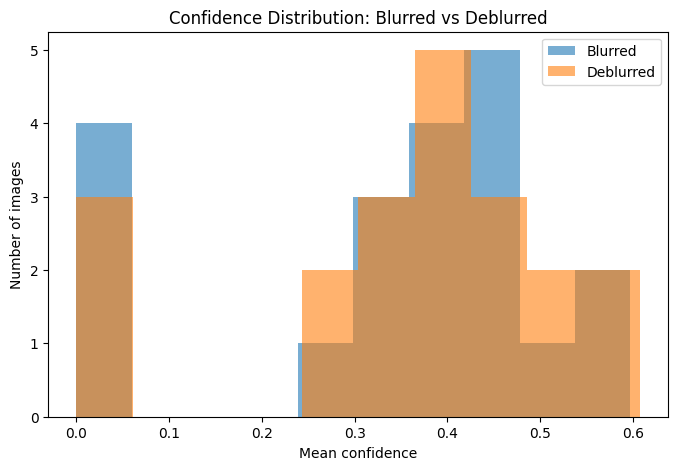

In [97]:
plt.figure(figsize=(8, 5))
plt.hist(task3_df["blur_mean_confidence"], bins=10, alpha=0.6, label="Blurred")
plt.hist(task3_df["deblur_mean_confidence"], bins=10, alpha=0.6, label="Deblurred")
plt.xlabel("Mean confidence")
plt.ylabel("Number of images")
plt.title("Confidence Distribution: Blurred vs Deblurred")
plt.legend()
plt.show()

In [98]:
print("Top images with confidence improvement:")
display(task3_df.sort_values("delta_confidence", ascending=False).head(5))

print("Top images with confidence decrease:")
display(task3_df.sort_values("delta_confidence", ascending=True).head(5))

Top images with confidence improvement:


,file_name,blur_num_detections,deblur_num_detections,blur_mean_confidence,deblur_mean_confidence,blur_classes,deblur_classes,delta_num_detections,delta_confidence
7,000008.png,0,1,0.000000,0.255802,,bowl,1,0.255802
15,000016.png,3,3,0.438850,0.499372,"bowl, potted plant","bowl, potted plant",0,0.060522
17,000018.png,1,1,0.492179,0.546902,potted plant,potted plant,0,0.054723
3,000004.png,4,4,0.363489,0.415234,"bowl, person, potted plant","bowl, person, potted plant",0,0.051745
5,000006.png,1,1,0.282505,0.327826,bowl,bowl,0,0.045321


Top images with confidence decrease:


,file_name,blur_num_detections,deblur_num_detections,blur_mean_confidence,deblur_mean_confidence,blur_classes,deblur_classes,delta_num_detections,delta_confidence
1,000002.png,2,3,0.461488,0.392522,bowl,"bowl, potted plant",1,-0.068966
12,000013.png,2,3,0.402236,0.348196,"bowl, train","bowl, car, train",1,-0.054039
2,000003.png,2,2,0.546285,0.522649,bowl,bowl,0,-0.023636
0,000001.png,1,1,0.324273,0.305592,car,car,0,-0.018682
10,000011.png,1,2,0.315749,0.300221,bowl,"bowl, person",1,-0.015527



Best Improvement Case: 000008.png


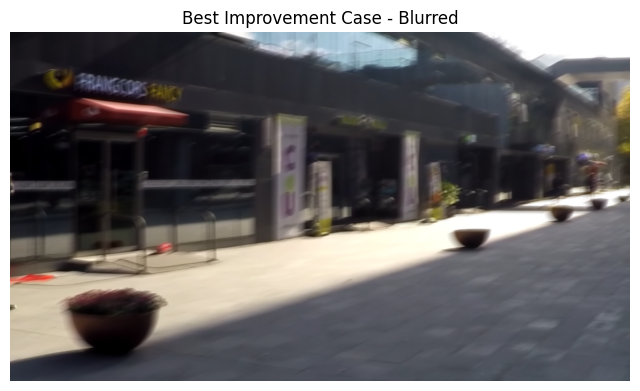

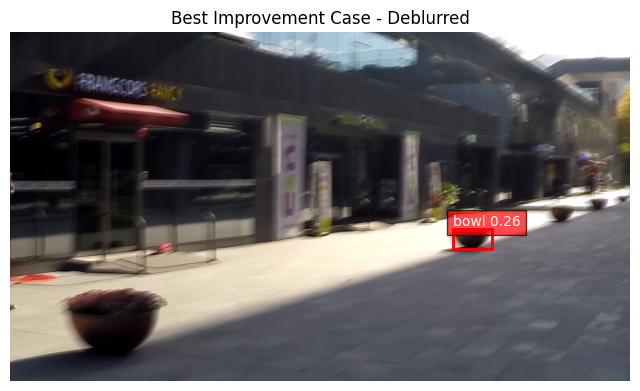


Worst Case: 000002.png


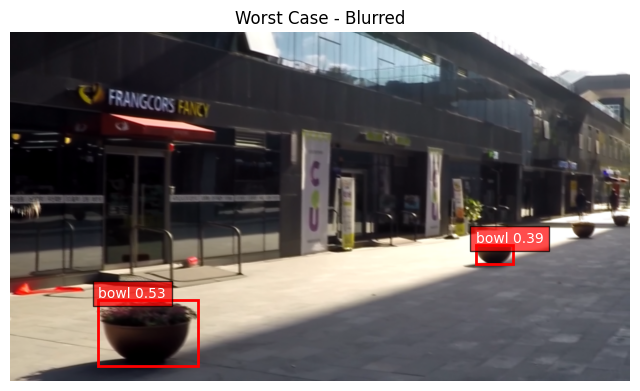

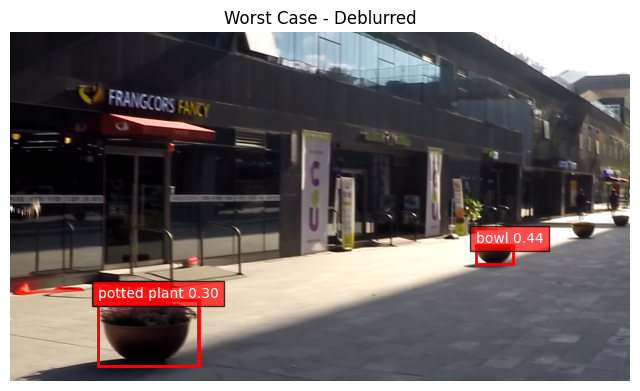

In [99]:
best_case = task3_df.sort_values("delta_confidence", ascending=False).iloc[0]["file_name"]
worst_case = task3_df.sort_values("delta_confidence", ascending=True).iloc[0]["file_name"]

for case_name, case_title in [(best_case, "Best Improvement Case"), (worst_case, "Worst Case")]:
    blur_path = os.path.join(blur_dir, case_name)
    blur_img_bgr = cv2.imread(blur_path)
    deblur_img_bgr = unsharp_mask(blur_img_bgr, kernel_size=(5, 5), sigma=1.0, amount=1.5)

    blur_result = run_detection_on_bgr(blur_img_bgr, detector, conf=0.25)
    deblur_result = run_detection_on_bgr(deblur_img_bgr, detector, conf=0.25)

    print(f"\n{case_title}: {case_name}")
    show_detection_result(blur_img_bgr, blur_result, title=f"{case_title} - Blurred")
    show_detection_result(deblur_img_bgr, deblur_result, title=f"{case_title} - Deblurred")

The Task 3 results show that applying unsharp masking before object detection produced mixed effects. 
On average, the deblurred images achieved slightly more detections and a slightly higher mean confidence score than the blurred images on this sample. 
However, the improvements were not consistent across all images, so the benefit of this simple restoration method appears limited.

## 12. Prepare Deblurred Dataset for Training

In [100]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil
import yaml

prepared_root = Path("prepared_dataset")
domains = ["blur", "deblur", "sharp"]
splits = ["train", "val", "test"]

for domain in domains:
    for split in splits:
        (prepared_root / domain / "images" / split).mkdir(parents=True, exist_ok=True)
        (prepared_root / domain / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Prepared dataset folders created under:", prepared_root.resolve())

Prepared dataset folders created under: D:\Jupyter_notebook\CV\Assignment1\prepared_dataset


In [101]:
deblur_dir = Path("data/deblur_unsharp")
deblur_dir.mkdir(parents=True, exist_ok=True)

generated_count = 0
for file_name in blur_files:
    blur_path = os.path.join(blur_dir, file_name)
    blur_img = cv2.imread(blur_path)

    if blur_img is None:
        print(f"Skipping unreadable image: {file_name}")
        continue

    deblur_img = unsharp_mask(
        blur_img,
        kernel_size=(5, 5),
        sigma=1.0,
        amount=1.5
    )

    save_path = deblur_dir / file_name
    cv2.imwrite(str(save_path), deblur_img)
    generated_count += 1

print(f"Saved {generated_count} deblurred images to: {deblur_dir}")

Saved 200 deblurred images to: data\deblur_unsharp


In [102]:
all_files = sorted([
    f for f in blur_files
    if os.path.exists(os.path.join(sharp_dir, f)) and os.path.exists(deblur_dir / f)
])

train_files, temp_files = train_test_split(
    all_files, test_size=0.30, random_state=42
)
val_files, test_files = train_test_split(
    temp_files, test_size=0.50, random_state=42
)

split_dict = {
    "train": train_files,
    "val": val_files,
    "test": test_files
}

for split_name, file_list in split_dict.items():
    print(split_name, len(file_list))

train 140
val 30
test 30


In [103]:
def copy_split_images(file_list, split_name):
    for file_name in file_list:
        src_blur = Path(blur_dir) / file_name
        src_deblur = deblur_dir / file_name
        src_sharp = Path(sharp_dir) / file_name

        shutil.copy(src_blur, prepared_root / "blur" / "images" / split_name / file_name)
        shutil.copy(src_deblur, prepared_root / "deblur" / "images" / split_name / file_name)
        shutil.copy(src_sharp, prepared_root / "sharp" / "images" / split_name / file_name)

for split_name, file_list in split_dict.items():
    copy_split_images(file_list, split_name)

print("All images copied into prepared_dataset.")

All images copied into prepared_dataset.


In [104]:
def save_yolo_labels_from_result(result, image_shape, label_path):
    h, w = image_shape[:2]
    lines = []

    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        with open(label_path, "w", encoding="utf-8") as f:
            f.write("")
        return 0

    for box in boxes:
        cls_id = int(box.cls.item())
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        x_center = ((x1 + x2) / 2) / w
        y_center = ((y1 + y2) / 2) / h
        bw = (x2 - x1) / w
        bh = (y2 - y1) / h

        lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}")

    with open(label_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    return len(lines)

In [105]:
pseudo_label_rows = []

for split_name, file_list in split_dict.items():
    for file_name in file_list:
        sharp_path = Path(sharp_dir) / file_name
        sharp_img = cv2.imread(str(sharp_path))

        if sharp_img is None:
            print(f"Skipping unreadable sharp image: {file_name}")
            continue

        sharp_rgb = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)

        # detector 是你前面 Task 3 已经加载好的 YOLO 模型
        results = detector.predict(sharp_rgb, conf=0.25, verbose=False)
        result = results[0]

        sharp_label_path = prepared_root / "sharp" / "labels" / split_name / file_name.replace(".png", ".txt")
        num_boxes = save_yolo_labels_from_result(result, sharp_img.shape, sharp_label_path)

        # 复制同样的标签到 blur / deblur
        blur_label_path = prepared_root / "blur" / "labels" / split_name / file_name.replace(".png", ".txt")
        deblur_label_path = prepared_root / "deblur" / "labels" / split_name / file_name.replace(".png", ".txt")

        shutil.copy(sharp_label_path, blur_label_path)
        shutil.copy(sharp_label_path, deblur_label_path)

        pseudo_label_rows.append({
            "split": split_name,
            "file_name": file_name,
            "num_boxes": num_boxes
        })

print("Pseudo-label generation completed.")

Pseudo-label generation completed.


In [106]:
pseudo_label_df = pd.DataFrame(pseudo_label_rows)
pseudo_label_df.head()

,split,file_name,num_boxes
0,train,000170.png,9
1,train,000098.png,2
2,train,000032.png,4
3,train,000013.png,4
4,train,000036.png,6


In [107]:
pseudo_label_summary = pseudo_label_df.groupby("split")["num_boxes"].agg(["count", "mean", "min", "max"]).reset_index()
pseudo_label_summary

,split,count,mean,min,max
0,test,30,8.333333,2,19
1,train,140,7.628571,0,20
2,val,30,7.566667,1,16


In [108]:
def get_detector_names(detector_model):
    names = detector_model.model.names
    if isinstance(names, dict):
        return names
    return {i: name for i, name in enumerate(names)}

class_names = get_detector_names(detector)

def write_domain_yaml(domain_name):
    yaml_data = {
        "path": str((prepared_root / domain_name).resolve()),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": class_names
    }

    yaml_path = prepared_root / f"{domain_name}.yaml"
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.dump(yaml_data, f, sort_keys=False, allow_unicode=True)

    return yaml_path

blur_yaml = write_domain_yaml("blur")
deblur_yaml = write_domain_yaml("deblur")
sharp_yaml = write_domain_yaml("sharp")

print("Created YAML files:")
print("blur  :", blur_yaml)
print("deblur:", deblur_yaml)
print("sharp :", sharp_yaml)

Created YAML files:
blur  : prepared_dataset\blur.yaml
deblur: prepared_dataset\deblur.yaml
sharp : prepared_dataset\sharp.yaml


In [109]:
from ultralytics import YOLO

train_model = YOLO("yolov8n.pt")

train_results = train_model.train(
    data=str(deblur_yaml),
    epochs=10,
    imgsz=640,
    batch=8,
    project="runs_deblur_train",
    name="yolov8n_deblur_finetune",
    pretrained=True,
    verbose=True
)

print("Training completed.")

Ultralytics 8.4.30  Python-3.10.11 torch-2.11.0+cpu CPU (Intel Core i7-14700KF)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=prepared_dataset\deblur.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_deblur_finetune2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100